# TAREA INDIVIDUAL 1
## Análisis Exploratorio de Datos y Predicción de Créditos mediante Machine Learning

**Estudiante:** Andrés Ñacato

**Módulo:** MTDI202 - Big Data, Analytics & Data Scientists

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Índice
1. Introducción
2. Carga de librerías
3. Carga y lectura del dataset
4. Descripción del dataset
5. Limpieza y preparación
6. Análisis exploratorio (EDA)
7. Visualizaciones
8. Machine Learning
9. Resultados
10. Conclusiones y recomendaciones

## 1. Introducción
El objetivo es analizar los factores que influyen en la aprobación de créditos y construir un modelo predictivo de Machine Learning.

## 2. Carga de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 3. Carga y Lectura del Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditos1.csv.csv')


In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## 4. Descripción del Dataset
Variable objetivo: Loan_Status

## 5. Limpieza y Preparación

In [ ]:
df.isnull().sum()


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.nunique()

,0
Loan_ID,614
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,203
Loan_Amount_Term,10


In [ ]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


## 6. Análisis Exploratorio de Datos

In [ ]:
df.describe()
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,614,614,614,614,614,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,502,401,360,480,532,233,422


In [ ]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [ ]:
df.groupby('Education')['LoanAmount'].mean()

,LoanAmount
Education,
Graduate,153.245833
Not Graduate,118.910448


In [ ]:
pd.crosstab(df['Education'], df['Loan_Status'])

Loan_Status,N,Y
Education,,
Graduate,140,340
Not Graduate,52,82


In [ ]:
pd.pivot_table(df, values='LoanAmount', index='Property_Area', aggfunc='mean')

,LoanAmount
Property_Area,
Rural,151.446927
Semiurban,145.128755
Urban,141.425743


## 7. Visualizaciones

In [ ]:
import plotly.express as px
fig = px.histogram(
    df,
    x="ApplicantIncome",
    title="Distribución de Ingresos del Solicitante",
    nbins=30
)
fig.show()


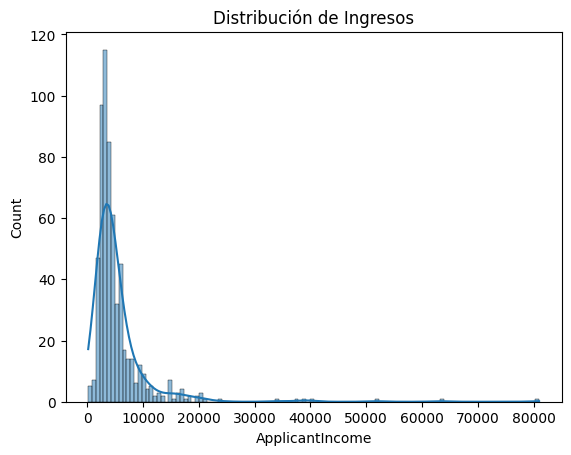

In [ ]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title('Distribución de Ingresos')
plt.show()

In [ ]:
fig = px.box(
    df,
    y="ApplicantIncome",
    title="Boxplot de Ingresos del Solicitante"
)
fig.show()


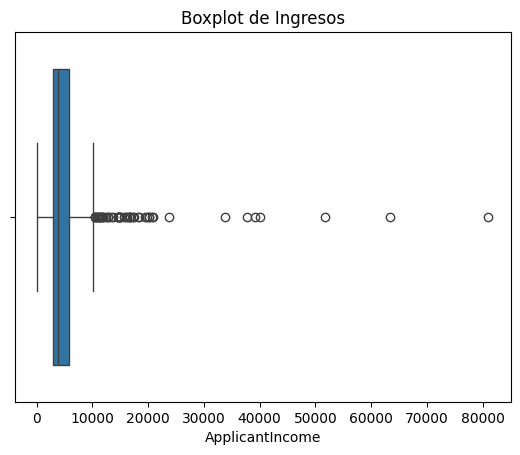

In [ ]:
sns.boxplot(x=df['ApplicantIncome'])
plt.title('Boxplot de Ingresos')
plt.show()

In [ ]:
fig = px.bar(
    df["Loan_Status"]
    .value_counts()
    .reset_index(),
    x="Loan_Status",
    y="count",
    title="Estado de Aprobación de Créditos"
)
fig.show()


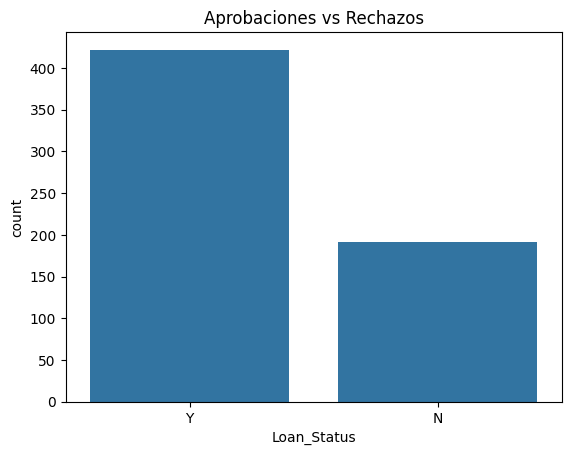

In [ ]:
sns.countplot(data=df,x='Loan_Status')
plt.title('Aprobaciones vs Rechazos')
plt.show()

In [ ]:
fig = px.pie(
    df,
    names="Loan_Status",
    title="Distribución de Créditos Aprobados y Rechazados",
    hole=0.4
)

fig.show()


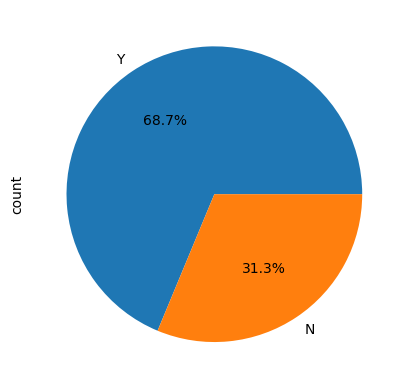

In [ ]:
df['Loan_Status'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

In [ ]:
fig = px.histogram(
    df,
    x="Education",
    color="Loan_Status",
    barmode="group",
    title="Educación y Estado del Crédito"
)
fig.show()


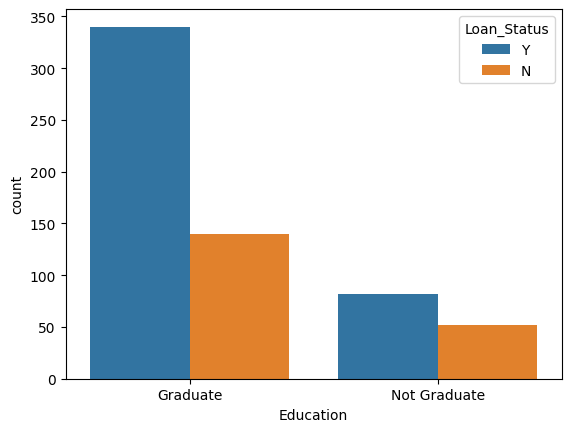

In [ ]:
sns.countplot(data=df,x='Education',hue='Loan_Status')
plt.show()

In [ ]:
fig = px.histogram(
    df,
    x="Property_Area",
    color="Loan_Status",
    barmode="group",
    title="Área Geográfica y Estado del Crédito"
)
fig.show()


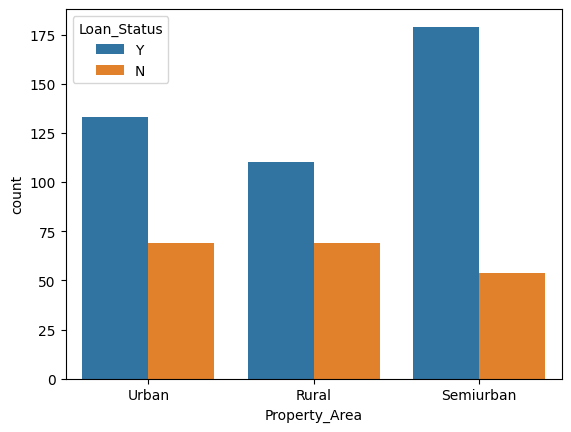

In [ ]:
sns.countplot(data=df,x='Property_Area',hue='Loan_Status')
plt.show()

In [ ]:
fig = px.scatter(
    df,
    x="ApplicantIncome",
    y="LoanAmount",
    color="Loan_Status",
    title="Ingresos vs Monto Solicitado"
)

fig.show()


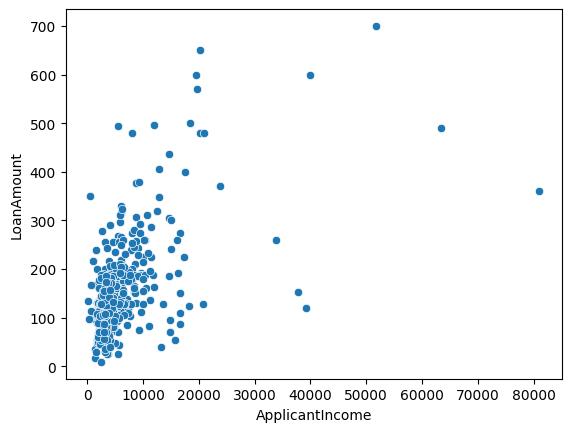

In [ ]:
sns.scatterplot(data=df,x='ApplicantIncome',y='LoanAmount')
plt.show()

In [ ]:
fig = px.violin(
    df,
    x="Loan_Status",
    y="ApplicantIncome",
    box=True,
    title="Distribución de Ingresos por Estado del Crédito"
)
fig.show()


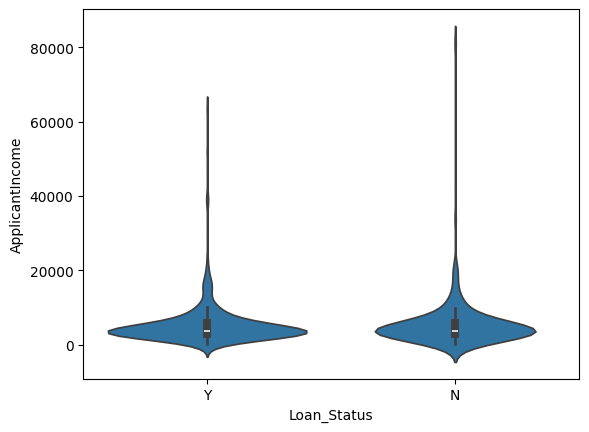

In [ ]:
sns.violinplot(data=df,x='Loan_Status',y='ApplicantIncome')
plt.show()

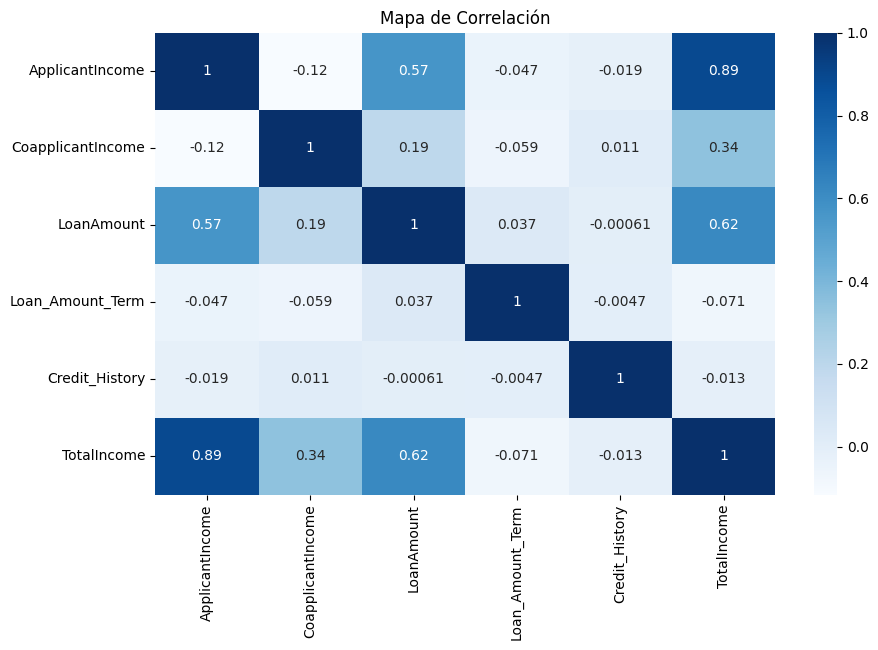

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Mapa de Correlación")
plt.show()


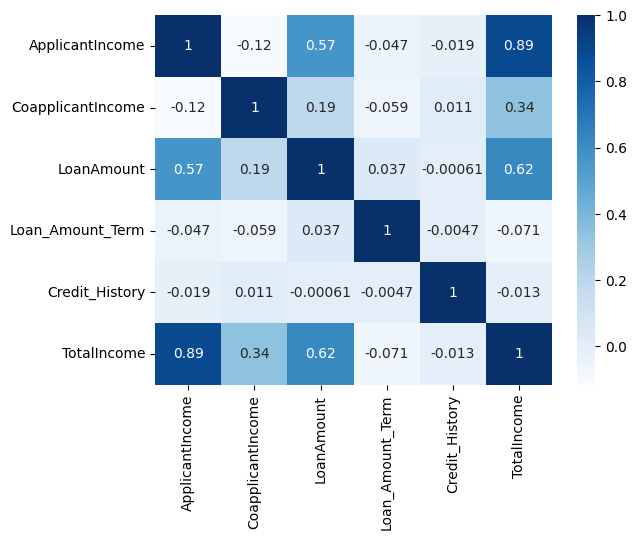

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap='Blues')
plt.show()

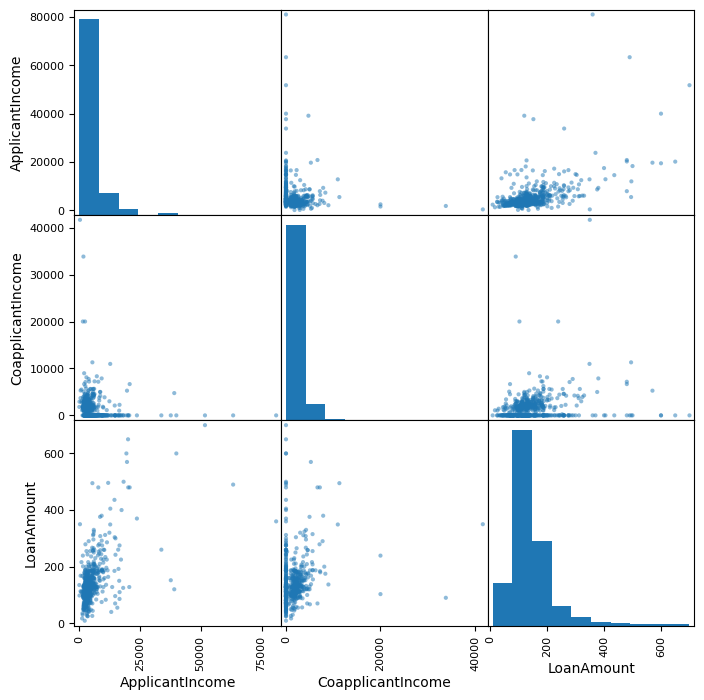

In [ ]:
scatter_matrix(df[['ApplicantIncome','CoapplicantIncome','LoanAmount']], figsize=(8,8))
plt.show()

## 8. Machine Learning

Preparación de variables:

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categoricas = [ 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status' ]
for col in categoricas:
    df[col] = le.fit_transform(df[col].astype(str))


In [ ]:
X = df.drop(
    ['Loan_Status', 'Loan_ID'],
    axis=1
)

y = df['Loan_Status']


División del Conjunto de Datos

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


Entrenamiento del modelo (Arbol de Decisión ):

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)


DecisionTreeClassifier(random_state=42)

Entrenamiento del modelo (Random Forest):

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)


RandomForestClassifier(n_estimators=200, random_state=42)

Generación de predicciones:

In [ ]:
tree_pred = tree.predict(X_test)

In [ ]:
rf_pred = rf.predict(X_test)

Comparación de modelos:

In [ ]:
from sklearn.metrics import accuracy_score

print("Decision Tree:",
      accuracy_score(
          y_test,
          tree_pred
      ))

print("Random Forest:",
      accuracy_score(
          y_test,
          rf_pred
      ))


Decision Tree: 0.6991869918699187
Random Forest: 0.7642276422764228


Evaluación del modelo seleccionado:

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    rf_pred
)


0.7642276422764228

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)


              precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



Matriz de confusión:

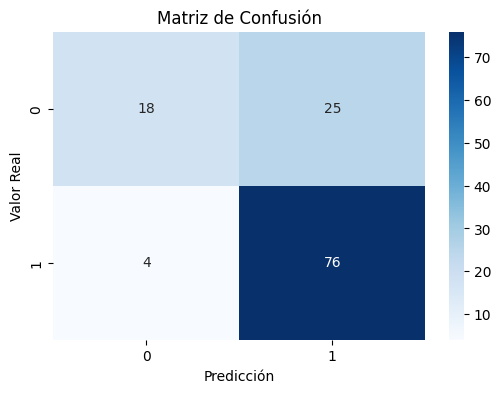

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    rf_pred
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()


Importancia de variables:

In [ ]:
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
})

importances = importances.sort_values(
    'Importancia',
    ascending=False
)

print(
    importances.head(10)
)


             Variable  Importancia
9      Credit_History     0.251290
11        TotalIncome     0.166264
5     ApplicantIncome     0.146325
7          LoanAmount     0.145558
6   CoapplicantIncome     0.086261
8    Loan_Amount_Term     0.046914
10      Property_Area     0.044339
2          Dependents     0.038635
1             Married     0.021040
3           Education     0.019840


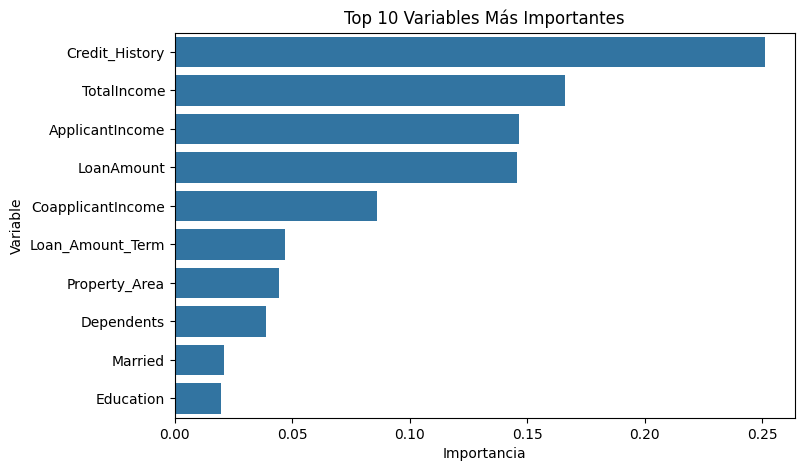

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importances.head(10),
    x='Importancia',
    y='Variable'
)

plt.title(
    'Top 10 Variables Más Importantes'
)

plt.show()


## 9. Resultados

- Identificar las variables más influyentes.
- Analizar el desempeño del modelo.
- Comparar aprobación y rechazo de créditos.


## 10. Conclusiones y Recomendaciones

### Conclusiones
1. El historial crediticio es el principal factor de aprobación.
2. Los ingresos tienen influencia moderada.
3. Random Forest ofrece un desempeño adecuado.

### Recomendaciones
1. Incorporar más variables históricas.
2. Aplicar validación cruzada.
3. Evaluar modelos avanzados como XGBoost.
